In [2]:
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [3]:
df=pd.read_csv("visitor_data.csv")

In [4]:
df.head()

,Visitor_ID,Name,Age,Ticket_Price,Check_In_Time,City,State
0,V1000,ABHISHEK SANDEEP ZADE,25.0,500.0,10:00 AM,Delhi,Delhi
1,V1001,ARNAV AJAY DESHPANDE..,23.0,750.0,10:30 AM,Aurangabad,Maharastra
2,V1002,.. .. ASHWINI LALCHAND MUNDAWARE/,22.0,500.0,11:00 AM,Mumbai,Maharastra
3,V1003,GAYATRI SURESH GAIKWAD,NaN,1000.0,11:30 AM,Bombay,Maharastra
4,V1004,HARSHADA GANESH CHAUDHARI,21.0,NaN,NaN,New Delhi,Delhi


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Visitor_ID     20 non-null     str    
 1   Name           18 non-null     str    
 2   Age            18 non-null     float64
 3   Ticket_Price   17 non-null     float64
 4   Check_In_Time  17 non-null     str    
 5   City           20 non-null     str    
 6   State          20 non-null     str    
dtypes: float64(2), str(5)
memory usage: 2.1 KB


In [6]:
df.describe()

,Age,Ticket_Price
count,18.000000,17.000000
mean,24.388889,711.764706
std,3.292396,170.045409
min,19.000000,500.000000
25%,22.250000,500.000000
50%,24.500000,750.000000
75%,25.750000,800.000000
max,31.000000,1000.000000


Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0
  visitor_id                               name   age  ticket_price  \
0      V1000              ABHISHEK SANDEEP ZADE  25.0         500.0   
1      V1001             ARNAV AJAY DESHPANDE..  23.0         750.0   
2      V1002  .. .. ASHWINI LALCHAND MUNDAWARE/  22.0         500.0   
3      V1003             GAYATRI SURESH GAIKWAD  24.5        1000.0   
4      V1004          HARSHADA GANESH CHAUDHARI  21.0         750.0   

  check_in_time        city       state  result  
0      10:00 AM       Delhi       Delhi       0  
1      10:30 AM  Aurangabad  Maharastra       1  
2      11:00 AM      Mumbai  Maharastra       0  
3      11:30 AM      Bombay  Maharastra       1  
4           NaN   New Delhi       Delhi       1  
        ticket_price     age
result                      
0         568.750000  24.625
1         816.666667  24.250


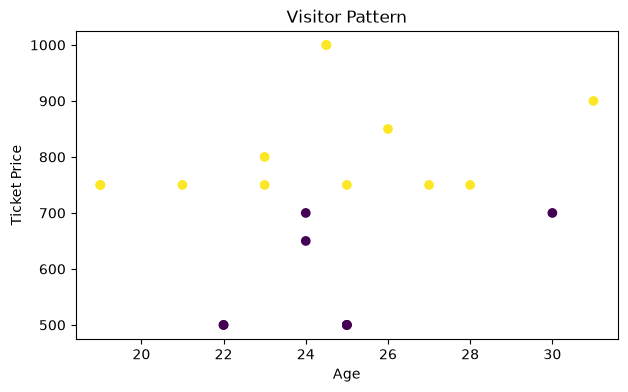

X shape: (20, 2)
y shape: (20,)
Training rows: 16
Testing rows : 4
Model trained!


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

df = pd.read_csv("visitor_data.csv")

df.columns = df.columns.str.strip().str.lower()

df["age"] = df["age"].fillna(df["age"].median())
df["ticket_price"] = df["ticket_price"].fillna(df["ticket_price"].median())

df["result"] = np.where(df["ticket_price"] >= df["ticket_price"].median(), 1, 0)

print(df.head())

print(df.groupby("result")[["ticket_price", "age"]].mean())

plt.figure(figsize=(7,4))
plt.scatter(df["age"], df["ticket_price"], c=df["result"])
plt.xlabel("Age")
plt.ylabel("Ticket Price")
plt.title("Visitor Pattern")
plt.show()

X = df[["age", "ticket_price"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")



In [17]:
prediction = model.predict(X_test)

In [18]:
print(prediction)

[0 0 1 1]


In [19]:
print(X_test)

     age  ticket_price
14  25.0         500.0
6   24.0         700.0
12  25.0         750.0
17  26.0         850.0


In [21]:
accuracy= accuracy_score(y_test, prediction)
print(f"test accuracy : {accuracy:.2%}")

test accuracy : 100.00%


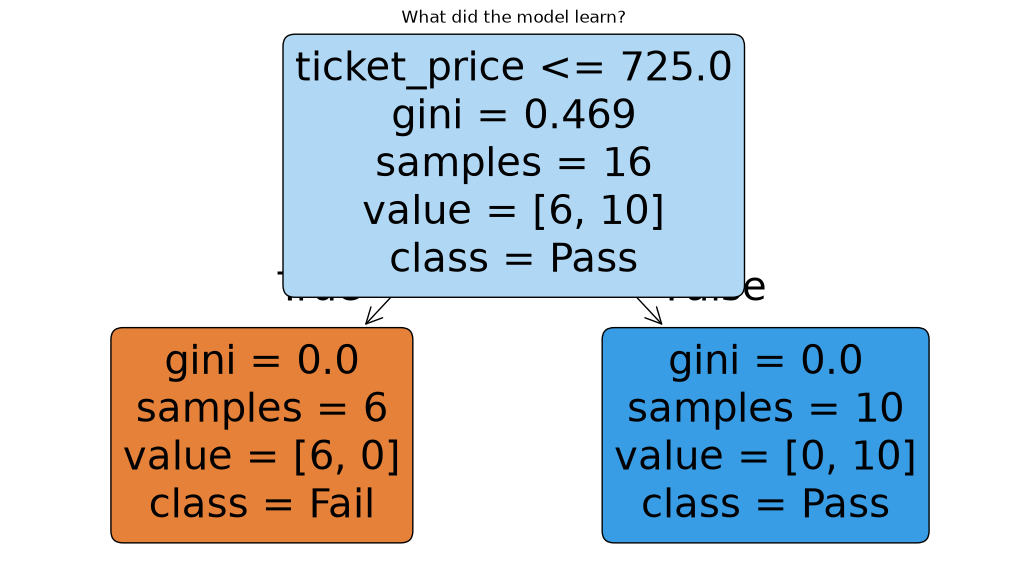

In [22]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()